# Homework Week 7

For this weeks homework, I have decided to  join the data sets for U.S states, large-scale Solar PV projects, and renewable energy production to understand how solar energy looks in each U.S state, and how much energy is actually generated from renewables in each state. 

One caviot of this assignment, is that the SolarPV dataset is from 2026, while the renewable energy generation dataset is from 2024. This poses a problem because renewable energy generation in 2026 could be different front 2024 because of energy advances, new infrastructure built and challenges due to the current political climate and administration. 


**1) Spatial Join: The first question I will be answering, is "How many large-scale solar PV projects are located in each state."**

This will be answered by spatially joining the Solar PV layer to the states layer usiing a "within" geographic join. Then I used the groupby function to join the results by each state

**2)Attribute Join: The second answer I will be looking for is "How much renewable energy is produced by each state,"** which will be found using an attribute join. The original CSV for renewable energy was complicated with blank rows and columns, so I used AI to clean the CSV to only include state names, and renewable energy production in trillion BTU. 

I found the answer to this question by joining the renewable enegry table to the states polygons using the state name. The difference between this question and the first question is that the first one used a "within" spatial join, and the second question matched records based on a share field name rather than location. 

**3)Different geoprocessing technique: The third answer I will be answering is "What states contain the greatest total land area of large-scale solar PV facilities?"** This question builds on the other two because it finds the total area of land that is occupied by solar PV facilities 

First step: load & inspect the data

In [2]:
import geopandas as gpd
import pandas as pd



In [3]:
SolarPV = gpd.read_file("solarPV.geojson")
States = gpd.read_file("./us_state/tl_2025_us_state.shp")


In [4]:
SolarPV.head()

,FID,Id,case_id,multi_poly,eia_id,p_state,p_county,ylat,xlong,p_area,...,p_azimuth,p_tilt,p_battery,p_cap_ac,p_cap_dc,p_type,p_agrivolt,p_comm,p_zscore,geometry
0,0,0,400011,single,2953,OK,Canadian,35.4774,-97.6764,50723,...,180.0,25.0,NaN,2.5,3.0,greenfield,non-agrivoltaic,community solar,-0.219022,"POLYGON ((-97.6768 35.47837, -97.67701 35.4783..."
1,1,0,407013,single,67406,NY,Erie,43.0168,-78.9779,77051,...,180.0,52.0,NaN,4.0,5.5,greenfield,non-agrivoltaic,community solar,-0.048823,"POLYGON ((-78.97948 43.01831, -78.97944 43.015..."
2,2,0,404351,single,64787,IL,Macoupin,39.4045,-90.0025,56943,...,25.0,NaN,NaN,2.0,3.0,greenfield,non-agrivoltaic,community solar,-0.308881,"POLYGON ((-90.00022 39.40521, -90.00142 39.405..."
3,3,0,404352,single,64788,NY,Greene,42.3708,-74.0406,40085,...,25.0,NaN,NaN,2.0,3.0,greenfield,non-agrivoltaic,community solar,-0.000703,"POLYGON ((-74.04066 42.3727, -74.04092 42.3727..."
4,4,0,404336,single,64734,IL,Stephenson,42.3804,-89.8412,55382,...,25.0,NaN,NaN,2.0,3.0,greenfield,non-agrivoltaic,community solar,-0.288227,"POLYGON ((-89.84004 42.38148, -89.84265 42.381..."


In [5]:
SolarPV.columns

Index(['FID', 'Id', 'case_id', 'multi_poly', 'eia_id', 'p_state', 'p_county',
       'ylat', 'xlong', 'p_area', 'p_img_date', 'p_dig_conf', 'p_name',
       'p_year', 'p_pwr_reg', 'p_tech_pri', 'p_tech_sec', 'p_sys_type',
       'p_axis', 'p_azimuth', 'p_tilt', 'p_battery', 'p_cap_ac', 'p_cap_dc',
       'p_type', 'p_agrivolt', 'p_comm', 'p_zscore', 'geometry'],
      dtype='str')

In [6]:
SolarPV.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [7]:
States.head()

,REGION,DIVISION,STATEFP,STATENS,GEOID,GEOIDFQ,STUSPS,NAME,LSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,1,2,36,01779796,36,0400000US36,NY,New York,00,G4000,A,122049344560,19256566831,+42.9133974,-075.5962723,"MULTIPOLYGON (((-74.72623 44.99486, -74.72257 ..."
1,4,8,32,01779793,32,0400000US32,NV,Nevada,00,G4000,A,284537074263,1839852286,+39.3310928,-116.6151469,"POLYGON ((-119.32418 41.99392, -119.32362 41.9..."
2,4,9,02,01785533,02,0400000US02,AK,Alaska,00,G4000,A,1479893380150,244326118163,+63.3473560,-152.8397334,"MULTIPOLYGON (((-167.55823 60.22436, -167.5567..."
3,9,0,60,01802701,60,0400000US60,AS,American Samoa,00,G4000,A,197759070,1307243751,-14.2668475,-170.6671854,"MULTIPOLYGON (((-168.22527 -14.53591, -168.224..."
4,1,1,50,01779802,50,0400000US50,VT,Vermont,00,G4000,A,23872664356,1030573104,+44.0589536,-072.6710173,"POLYGON ((-72.04187 44.15665, -72.0418 44.1566..."


In [8]:
States.columns

Index(['REGION', 'DIVISION', 'STATEFP', 'STATENS', 'GEOID', 'GEOIDFQ',
       'STUSPS', 'NAME', 'LSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER',
       'INTPTLAT', 'INTPTLON', 'geometry'],
      dtype='str')

In [9]:
States.crs

<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - onshore and offshore: Canada - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon. Puerto Rico. United States (USA) - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Hawaii; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming. US Virgin Islands. British Virgin Islands

In [10]:
SolarPV = SolarPV.to_crs(States.crs) #change crs to match 

In [11]:
SolarPV.crs #check both crs
States.crs

<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - onshore and offshore: Canada - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon. Puerto Rico. United States (USA) - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Hawaii; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming. US Virgin Islands. British Virgin Islands

In [12]:
SolarPV.geom_type.value_counts() #it includes polygons and multipolygons which 
                                #could be a problem since its not technically "point" data but for my evaluation this is okay

Polygon         3529
MultiPolygon    3082
Name: count, dtype: int64

In [13]:
SolarPV.total_bounds #check the bounds for .plot()

array([-162.55713535,   19.65529933,  -67.45975666,   66.83988864])

<Axes: xlabel='Geodetic longitude [degree]', ylabel='Geodetic latitude [degree]'>

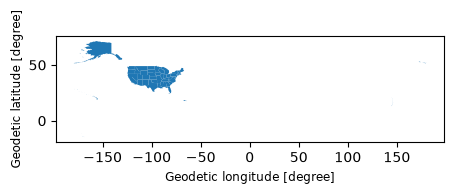

In [14]:
# plot the US map data 
States.plot(figsize=(5, 5))

<Axes: xlabel='Geodetic longitude [degree]', ylabel='Geodetic latitude [degree]'>

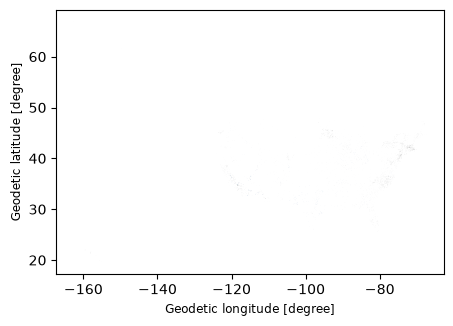

In [15]:
SolarPV.plot(figsize=(5, 5)) #hm no data?

(24.0, 50.0)

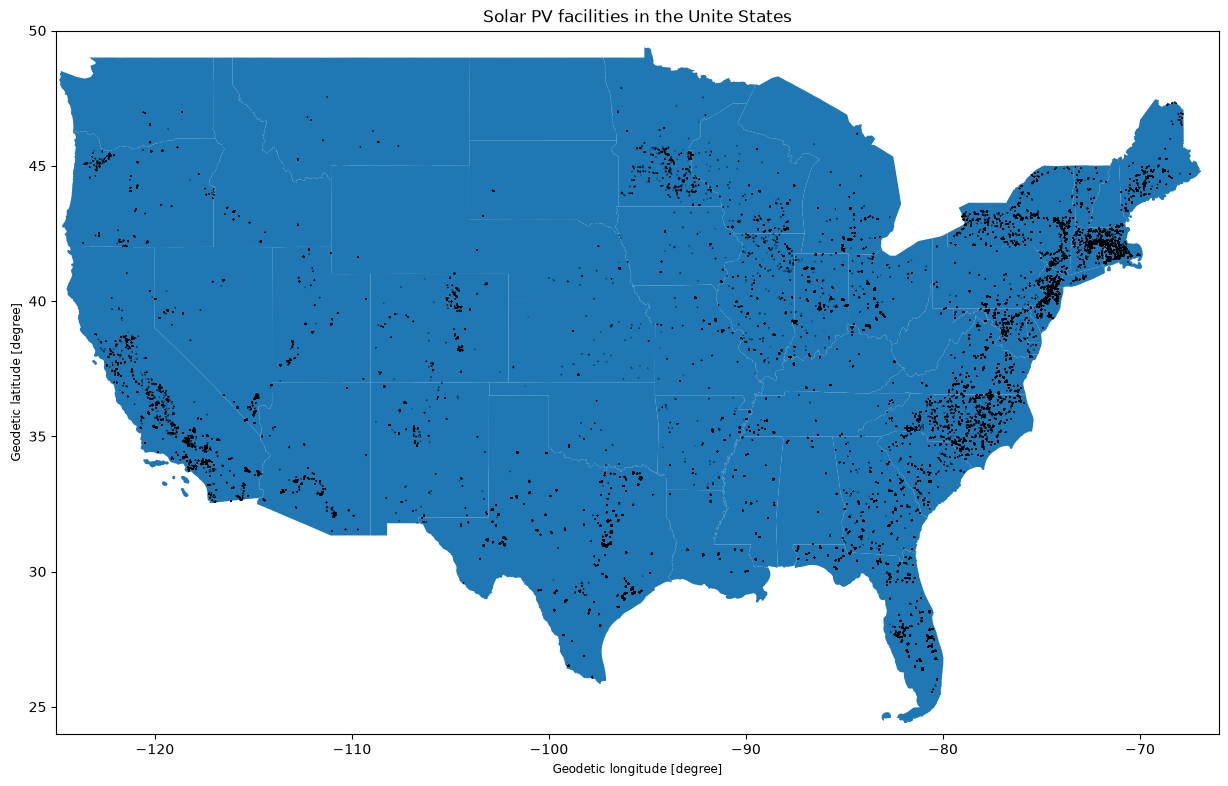

In [ ]:
ax = States.plot(figsize=(15, 10)) #combine the map

SolarPV.plot(
    ax=ax,
    edgecolor="black"
)
ax.set_title("Solar PV facilities in the United States")

ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)

# 1) Spatial Join: How many Solar PV facilities are there in each U.S. State?

In [17]:
solar_states = gpd.sjoin(SolarPV, States, predicate="within")

In [18]:
solar_states.columns #the join worked

Index(['FID', 'Id', 'case_id', 'multi_poly', 'eia_id', 'p_state', 'p_county',
       'ylat', 'xlong', 'p_area', 'p_img_date', 'p_dig_conf', 'p_name',
       'p_year', 'p_pwr_reg', 'p_tech_pri', 'p_tech_sec', 'p_sys_type',
       'p_axis', 'p_azimuth', 'p_tilt', 'p_battery', 'p_cap_ac', 'p_cap_dc',
       'p_type', 'p_agrivolt', 'p_comm', 'p_zscore', 'geometry', 'index_right',
       'REGION', 'DIVISION', 'STATEFP', 'STATENS', 'GEOID', 'GEOIDFQ',
       'STUSPS', 'NAME', 'LSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER',
       'INTPTLAT', 'INTPTLON'],
      dtype='str')

In [19]:
# count by states 
solar_count = solar_states.groupby("NAME").size()

In [31]:
#make it into a new dataframe to clearly represent the total count of facilities in each state then put it in order
solar_count = solar_states.groupby("NAME").size().reset_index()

solar_count.columns = ["NAME", "solar_pv_count"]

solar_count = solar_count.sort_values( "solar_pv_count",ascending=True)
solar_count



,NAME,solar_pv_count
29,New Hampshire,1
49,Wyoming,2
1,Alaska,2
40,South Dakota,3
47,West Virginia,4
46,Washington,7
26,Montana,9
0,Alabama,11
12,Idaho,13
8,District of Columbia,14


# 2) Attribute Join : How much renewable energy did each state produce in 2024?

In [21]:
renewable = pd.read_csv("RenewableEnergyData_Clean.csv")

In [22]:
renewable.head()

,NAME,Renewable_Energy_Trillion_Btu
0,Iowa,825.5
1,Texas,789.0
2,California,750.3
3,Illinois,359.8
4,Washington,356.7


In [23]:
States.head()

,REGION,DIVISION,STATEFP,STATENS,GEOID,GEOIDFQ,STUSPS,NAME,LSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,1,2,36,01779796,36,0400000US36,NY,New York,00,G4000,A,122049344560,19256566831,+42.9133974,-075.5962723,"MULTIPOLYGON (((-74.72623 44.99486, -74.72257 ..."
1,4,8,32,01779793,32,0400000US32,NV,Nevada,00,G4000,A,284537074263,1839852286,+39.3310928,-116.6151469,"POLYGON ((-119.32418 41.99392, -119.32362 41.9..."
2,4,9,02,01785533,02,0400000US02,AK,Alaska,00,G4000,A,1479893380150,244326118163,+63.3473560,-152.8397334,"MULTIPOLYGON (((-167.55823 60.22436, -167.5567..."
3,9,0,60,01802701,60,0400000US60,AS,American Samoa,00,G4000,A,197759070,1307243751,-14.2668475,-170.6671854,"MULTIPOLYGON (((-168.22527 -14.53591, -168.224..."
4,1,1,50,01779802,50,0400000US50,VT,Vermont,00,G4000,A,23872664356,1030573104,+44.0589536,-072.6710173,"POLYGON ((-72.04187 44.15665, -72.0418 44.1566..."


In [24]:
#join the data by using the name field in both data sets
states_renewable = States.merge( renewable, on="NAME", how="left")
states_renewable.head()

,REGION,DIVISION,STATEFP,STATENS,GEOID,GEOIDFQ,STUSPS,NAME,LSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry,Renewable_Energy_Trillion_Btu
0,1,2,36,01779796,36,0400000US36,NY,New York,00,G4000,A,122049344560,19256566831,+42.9133974,-075.5962723,"MULTIPOLYGON (((-74.72623 44.99486, -74.72257 ...",226.9
1,4,8,32,01779793,32,0400000US32,NV,Nevada,00,G4000,A,284537074263,1839852286,+39.3310928,-116.6151469,"POLYGON ((-119.32418 41.99392, -119.32362 41.9...",75.3
2,4,9,02,01785533,02,0400000US02,AK,Alaska,00,G4000,A,1479893380150,244326118163,+63.3473560,-152.8397334,"MULTIPOLYGON (((-167.55823 60.22436, -167.5567...",9.9
3,9,0,60,01802701,60,0400000US60,AS,American Samoa,00,G4000,A,197759070,1307243751,-14.2668475,-170.6671854,"MULTIPOLYGON (((-168.22527 -14.53591, -168.224...",NaN
4,1,1,50,01779802,50,0400000US50,VT,Vermont,00,G4000,A,23872664356,1030573104,+44.0589536,-072.6710173,"POLYGON ((-72.04187 44.15665, -72.0418 44.1566...",18.8


In [25]:
#keep only these columns & make them from least to most production

states_renewable_geom = states_renewable[["NAME","Renewable_Energy_Trillion_Btu","geometry"]]
states_renewable_geom = states_renewable_geom.sort_values( "Renewable_Energy_Trillion_Btu",ascending=True)
states_renewable_geom

,NAME,Renewable_Energy_Trillion_Btu,geometry
21,District of Columbia,1.9,"POLYGON ((-77.11975 38.93435, -77.11886 38.935..."
6,Delaware,2.9,"POLYGON ((-75.50949 39.68652, -75.50942 39.686..."
34,Rhode Island,7.9,"MULTIPOLYGON (((-71.20837 41.6906, -71.20829 4..."
2,Alaska,9.9,"MULTIPOLYGON (((-167.55823 60.22436, -167.5567..."
25,Hawaii,17.9,"MULTIPOLYGON (((-178.44359 28.41899, -178.4383..."
4,Vermont,18.8,"POLYGON ((-72.04187 44.15665, -72.0418 44.1566..."
29,West Virginia,19.4,"POLYGON ((-77.75438 39.33346, -77.75422 39.333..."
33,Maryland,31.1,"POLYGON ((-75.756 39.24607, -75.75578 39.24334..."
36,New Hampshire,31.4,"POLYGON ((-70.83887 43.24449, -70.83886 43.244..."
14,Utah,34.4,"POLYGON ((-111.50781 41.99955, -111.50727 41.9..."


## Second geoprocessing method to find:  "What states contain the greatest total land area of large-scale solar PV facilities?"

first thing is I have to convert is the solarPV data set to a different EPSG since EPSG:4269 uses degrees not feet, and to find area it should be changed to a EPSG for feet. The internet told me to use EPSG: 5070, NAD83 equivalent. 

In [32]:
solar_area = SolarPV.copy()
solar_area = SolarPV.to_crs(epsg=5070)
#find the area 
solar_area["area_m2"] = solar_area.geometry.area

#find acres (1 acre = 4046.86 m^2)
solar_area["area_acres"] = solar_area["area_m2"] / 4046.86

In [ ]:
states = States.copy()
states_5070 = States.to_crs(epsg=5070)

#spatial join 
solar_area_states = gpd.sjoin(solar_area,states_5070, predicate="within")

#groupby state and get the sum of total acres for each facility 
state_solar_area = solar_area_states.groupby("NAME")["area_acres"].sum()

#back to a normal table!!!
state_solar_area = state_solar_area.reset_index()

# get in order
state_solar_area = state_solar_area.sort_values( "area_acres",ascending=False)
state_solar_area

,NAME,area_acres
42,Texas,143025.028849
4,California,125619.435678
9,Florida,52634.387380
33,North Carolina,32467.282722
2,Arizona,31359.308401
28,Nevada,28577.764097
10,Georgia,28216.428801
45,Virginia,21948.126533
34,Ohio,20361.931940
14,Indiana,17528.858581


# Visualization 

Now I will make a few chloropleth maps to show the different data to show corelation between solar PV and renewable energy production: showing that Solar PV is one of the largest renewable energy sources in the United States. 

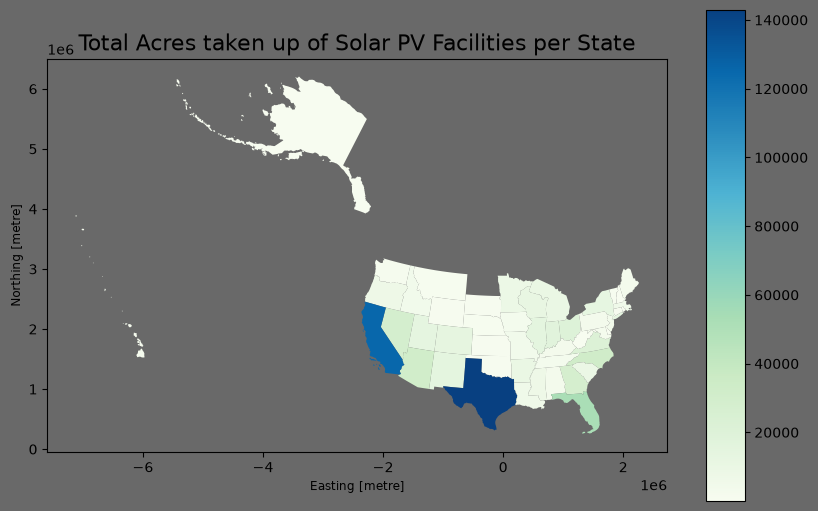

In [34]:
states_area = states_5070.merge( state_solar_area,on="NAME", how="left")
ax = states_area.plot(
    column="area_acres",
    cmap="GnBu",
    legend=True,
    figsize=(10, 10)
)

ax.set_title(
    "Total Acres taken up of Solar PV Facilities per State",
    fontsize=16
)
ax.set_facecolor("dimgray")
ax.figure.set_facecolor("dimgray")

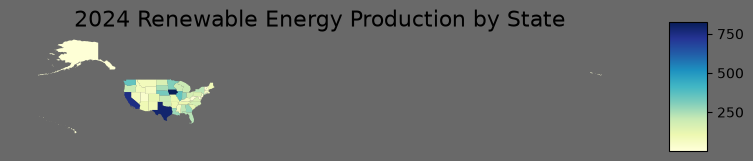

In [29]:
ax = states_renewable.plot(
    column="Renewable_Energy_Trillion_Btu",
    cmap="YlGnBu",
    legend=True,
    figsize=(10, 10),
)

ax.set_title(
    "2024 Renewable Energy Production by State",
    fontsize=16
)

ax.set_facecolor("dimgray")
ax.figure.set_facecolor("dimgray")
ax.set_axis_off()

Text(0.5, 1.0, 'Top 10 States by Large-Scale Solar PV Area')

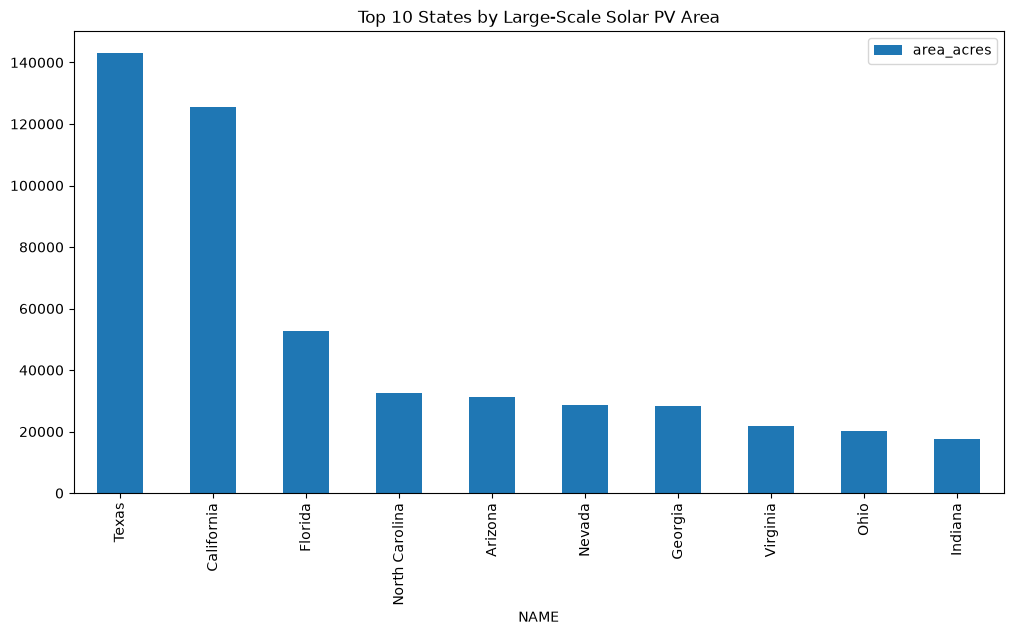

In [ ]:
top10 = state_solar_area.nlargest(10, "area_acres")

ax = top10.plot(
    x="NAME",
    y="area_acres",
    kind="bar",
    figsize=(12, 6)
)

ax.set_title("Top 10 States by Large-Scale Solar PV Area")


As a result, Texas, California and Flordia are the top three states which have the most land taken up for Solar PV energy production. These three states make the most sense as they have a lot of sunshine and are known for their high temperatures. A common name for California is "The Sunshine State." From my previous courses, I have learned that Texas and California have one of the largest solar energy productions to their energy grids, and this visualization verifies that. 

I am a little but surprised that Arizona and Nevada doesnt have more Solar PV

**AI Use**

For this assigment I used AI to assist me with parts of code for the .plot() parameters, errors, and csv data cleaning. I want to preface this by saying I have not taken a python class previously, therefore I used AI to guide me through this assignment where I needed it. For the most part, I did a lot of the code myself from our previous classes. The code I did was pretty easy things but the area of concern I really had AI make me code was for the visuals above. I needed help with the .plot() function as I am not well versed in making visualizations in code and the various items needed to create the map. I did learn ggplot and other code functions in Rmarkdown, but not python.  

I used AI to help me clean the Renewable Energy Data CSV. I downloaded it from the EIA website, but the first couple of columns were blank and some rows did not have information, etc. For time, I asked it to clean it down to states and renewable energy generation for a easier table join. 

Lastly, I used it to help me identify errors. i had a few errors during this assignment. I actually deleted all of my work on accident and I asked AI but I did not understand what it was saying to do so I just redid the assignment and cleaned it up. Lastly, I got errors on a few of my codes because I did not make a copy of the data set or change the name and that was a problem for me. 